# Analyse exploratoire des données

## importation et apercu des données 

In [1]:
import pandas as pd


In [2]:
import pandas as pd

file = "Customer_Churn_Data_Large.xlsx"

dem = pd.read_excel(file, sheet_name="Customer_Demographics")
trans = pd.read_excel(file, sheet_name="Transaction_History")
service = pd.read_excel(file, sheet_name="Customer_Service")
churn = pd.read_excel(file, sheet_name="Churn_Status")
online = pd.read_excel(file, sheet_name="Online_Activity")

In [3]:
df = trans.merge(dem, on="CustomerID", how="left")

In [4]:
df = df.merge(service, on="CustomerID", how="left")

In [5]:
df = df.merge(churn, on="CustomerID", how="left")

In [6]:
df= df.merge(online, on="CustomerID", how="left")

In [7]:
df.head(10)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,Age,Gender,MaritalStatus,IncomeLevel,InteractionID,InteractionDate,InteractionType,ResolutionStatus,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage
0,1,7194,2022-03-27,416.50,Electronics,62,M,Single,Low,6363.0,2022-03-31,Inquiry,Resolved,0,2023-10-21,34,Mobile App
1,2,7250,2022-08-08,54.96,Clothing,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
2,2,9660,2022-07-25,197.50,Electronics,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
3,2,2998,2022-01-25,101.31,Furniture,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
4,2,1228,2022-07-24,397.37,Clothing,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
5,2,8903,2022-01-09,285.21,Electronics,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
6,2,3527,2022-09-16,311.34,Electronics,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
7,2,9279,2022-11-19,199.73,Groceries,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
8,3,9839,2022-10-08,241.06,Books,18,M,Single,Low,9976.0,2022-08-24,Inquiry,Resolved,0,2023-11-15,3,Website
9,3,7364,2022-08-15,51.07,Clothing,18,M,Single,Low,9976.0,2022-08-24,Inquiry,Resolved,0,2023-11-15,3,Website


In [8]:
# stats descriptives sauf les dates ,costumerID, transactionID, ChurnStatus qui sont des identifiants et la variable cible 
df.describe(exclude=['datetime64', 'object'])

,CustomerID,TransactionID,AmountSpent,Age,InteractionID,ChurnStatus,LoginFrequency
count,6812.000000,6812.000000,6812.000000,6812.000000,5204.000000,6812.000000,6812.000000
mean,500.169260,5497.323253,251.620527,43.274516,5921.861261,0.198473,25.724310
std,286.704642,2584.768541,142.901693,15.286788,2332.331260,0.398880,14.062032
min,1.000000,1000.000000,5.180000,18.000000,2015.000000,0.000000,1.000000
25%,247.000000,3223.500000,127.100000,30.000000,3873.250000,0.000000,14.000000
50%,505.500000,5515.000000,251.845000,44.000000,5903.000000,0.000000,26.000000
75%,750.000000,7675.250000,375.280000,56.000000,7851.000000,0.000000,38.000000
max,1000.000000,9997.000000,499.860000,69.000000,9997.000000,1.000000,49.000000


## detection des anomalies 

In [9]:
#verification des doublons et leur pourcentage dans le dataset
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
total_rows = len(df)
percentage_duplicates = (num_duplicates / total_rows) * 100
print(f"Nombre de doublons : {num_duplicates}")
print(f"Pourcentage de doublons : {percentage_duplicates:.2f}%")






Nombre de doublons : 0
Pourcentage de doublons : 0.00%


In [10]:
# detection des valeurs manquantes et leur pourcentage dans le dataset de chaque colonne
missing_values = df.isnull().sum()
total_rows = len(df)
percentage_missing = (missing_values / total_rows) * 100
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing': percentage_missing
})
print(missing_data)


                  Missing Values  Percentage Missing
CustomerID                     0            0.000000
TransactionID                  0            0.000000
TransactionDate                0            0.000000
AmountSpent                    0            0.000000
ProductCategory                0            0.000000
Age                            0            0.000000
Gender                         0            0.000000
MaritalStatus                  0            0.000000
IncomeLevel                    0            0.000000
InteractionID               1608           23.605402
InteractionDate             1608           23.605402
InteractionType             1608           23.605402
ResolutionStatus            1608           23.605402
ChurnStatus                    0            0.000000
LastLoginDate                  0            0.000000
LoginFrequency                 0            0.000000
ServiceUsage                   0            0.000000


In [11]:
# verification des types de données 
print(df.dtypes)


CustomerID                   int64
TransactionID                int64
TransactionDate     datetime64[ns]
AmountSpent                float64
ProductCategory             object
Age                          int64
Gender                      object
MaritalStatus               object
IncomeLevel                 object
InteractionID              float64
InteractionDate     datetime64[ns]
InteractionType             object
ResolutionStatus            object
ChurnStatus                  int64
LastLoginDate       datetime64[ns]
LoginFrequency               int64
ServiceUsage                object
dtype: object


## exploration des donnees 

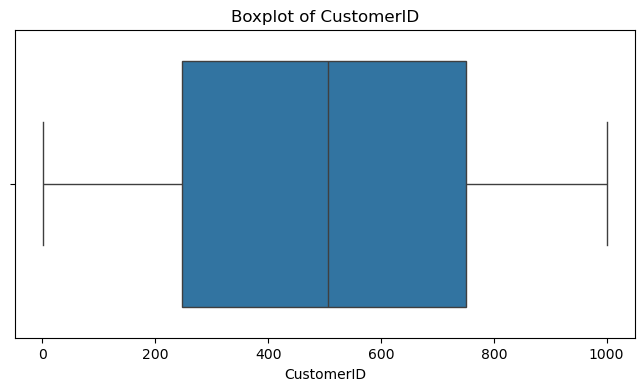

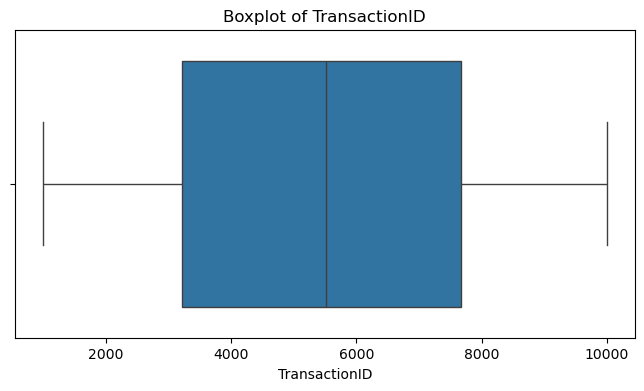

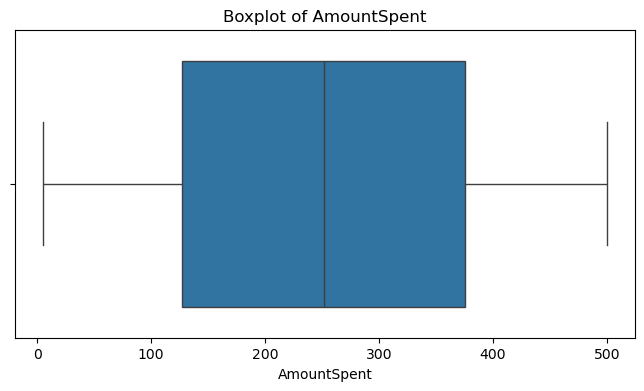

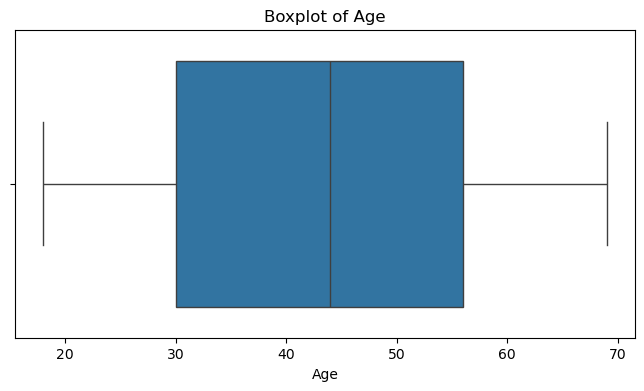

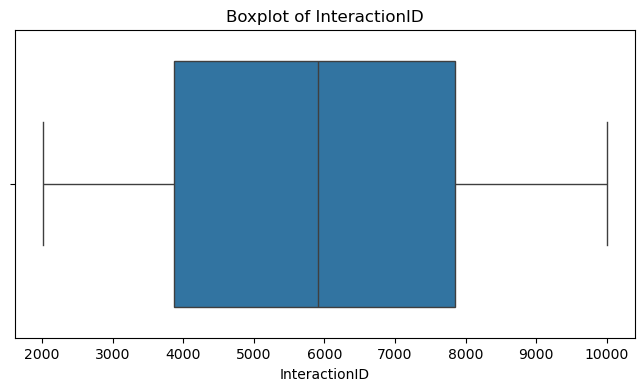

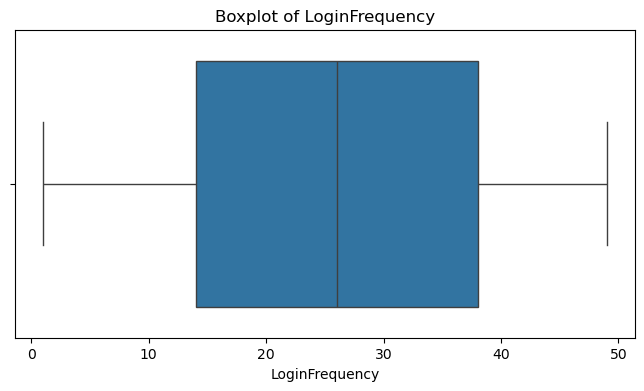

In [12]:
# distribution et verification des outliers avec les boxplots pour les variables numériques sans la variable cible "ChurnStatus"
import matplotlib.pyplot as plt 
import seaborn as sns   
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('ChurnStatus')
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

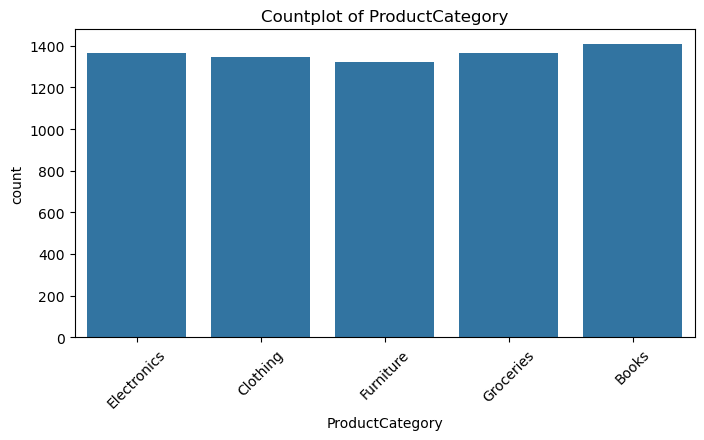

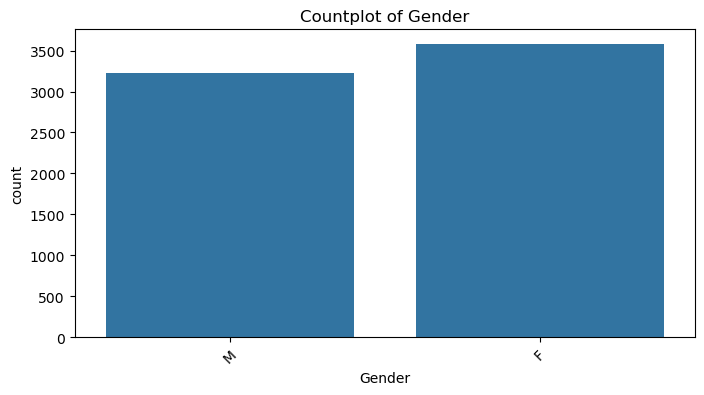

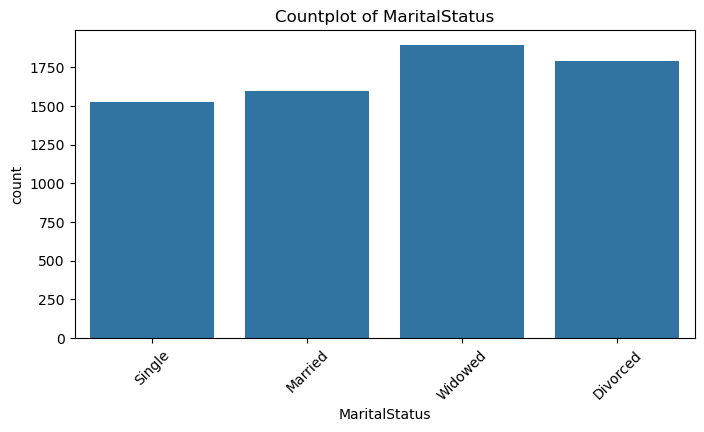

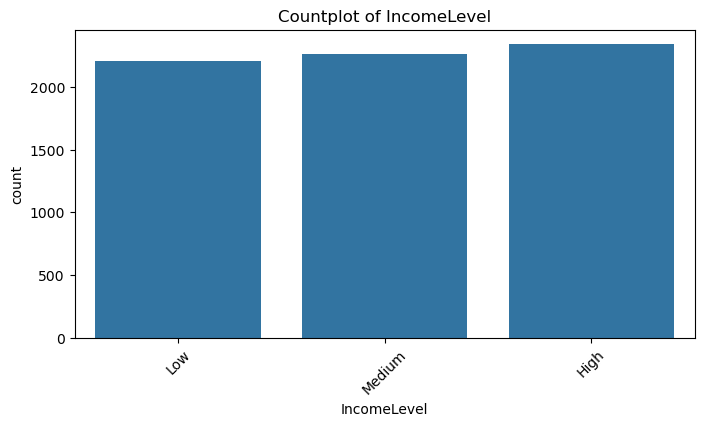

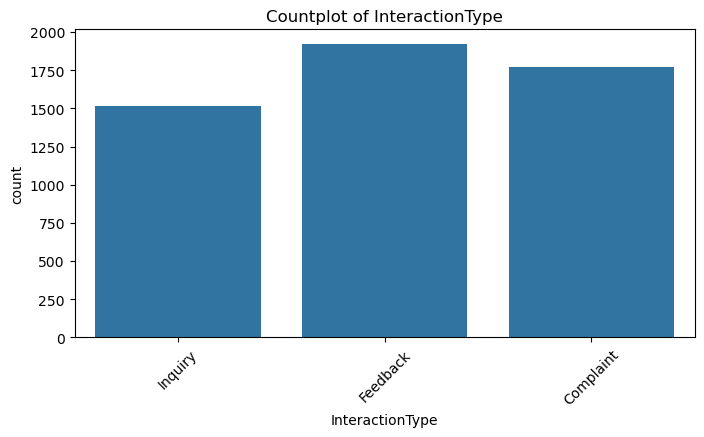

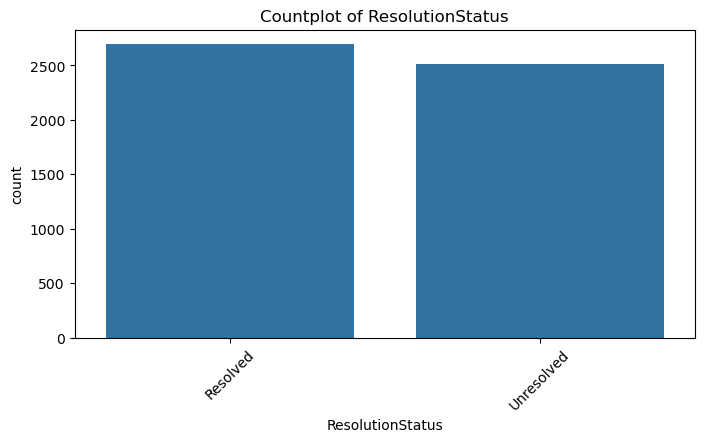

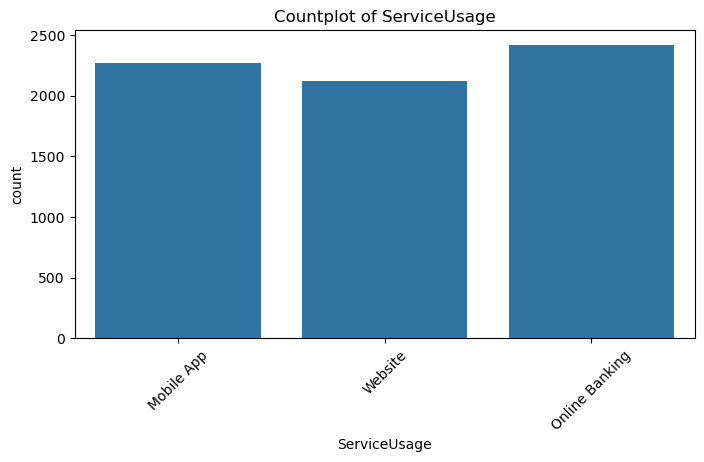

In [13]:
# distribution des variables catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

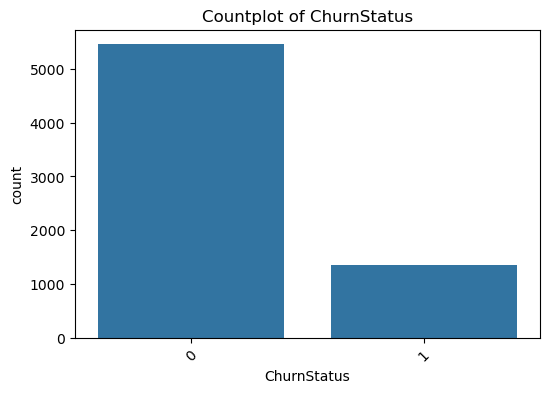

In [14]:
# distribution de la variable cible "ChurnStatus"
plt.figure(figsize=(6, 4))
sns.countplot(x=df['ChurnStatus'])
plt.title('Countplot of ChurnStatus')
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Correlation Matrix of Numerical Variables')

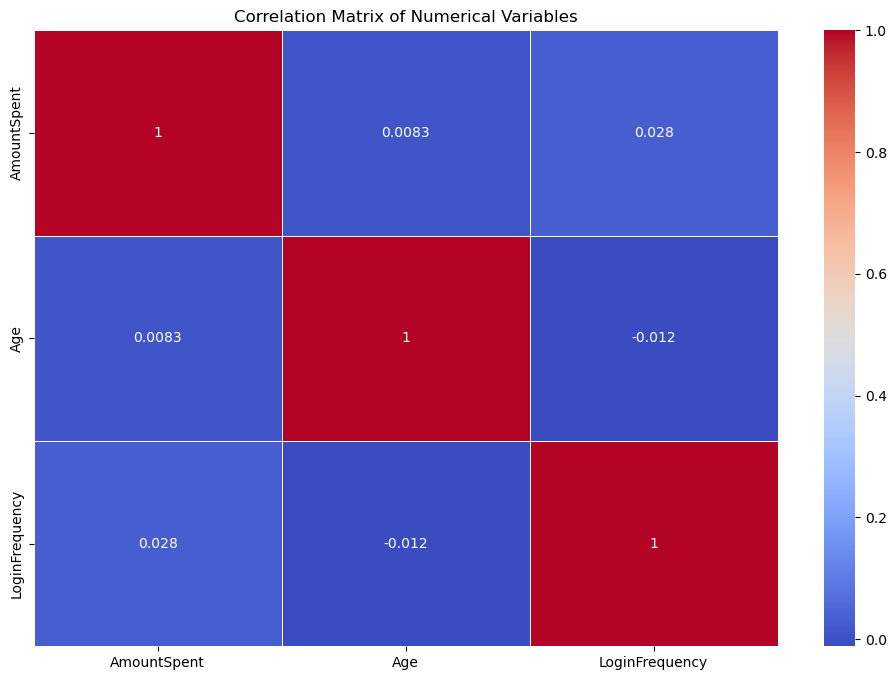

In [15]:
# matrice de correlation pour les variables numeriques sauf costumerID, transactionID qui sont des identifiants et la variable cible
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['CustomerID', 'TransactionID', 'InteractionID', 'ChurnStatus'])
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')


In [16]:
# tableau de contigence entre les variables catégorielles et la variable cible "ChurnStatus"
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['ChurnStatus'])
    print(f"Contingency Table for {col} and ChurnStatus:")
    print(contingency_table)
    print("\n")
    

Contingency Table for ProductCategory and ChurnStatus:
ChurnStatus         0    1
ProductCategory           
Books            1146  262
Clothing         1096  252
Electronics      1064  302
Furniture        1053  271
Groceries        1101  265


Contingency Table for Gender and ChurnStatus:
ChurnStatus     0    1
Gender                
F            2924  656
M            2536  696


Contingency Table for MaritalStatus and ChurnStatus:
ChurnStatus       0    1
MaritalStatus           
Divorced       1458  335
Married        1258  337
Single         1196  332
Widowed        1548  348


Contingency Table for IncomeLevel and ChurnStatus:
ChurnStatus     0    1
IncomeLevel           
High         1940  400
Low          1730  477
Medium       1790  475


Contingency Table for InteractionType and ChurnStatus:
ChurnStatus         0    1
InteractionType           
Complaint        1399  370
Feedback         1523  398
Inquiry          1210  304


Contingency Table for ResolutionStatus and ChurnS

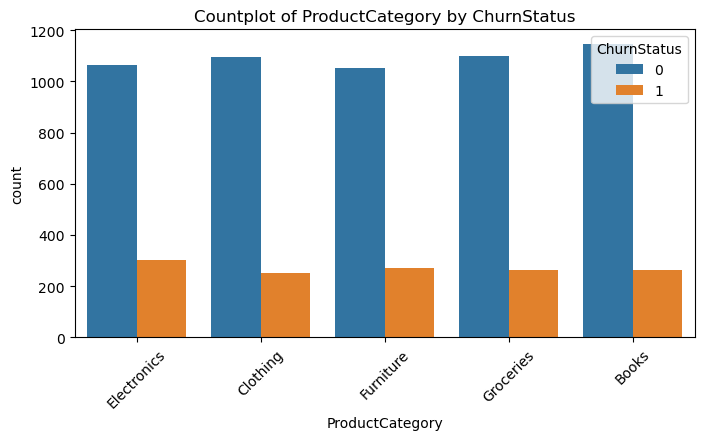

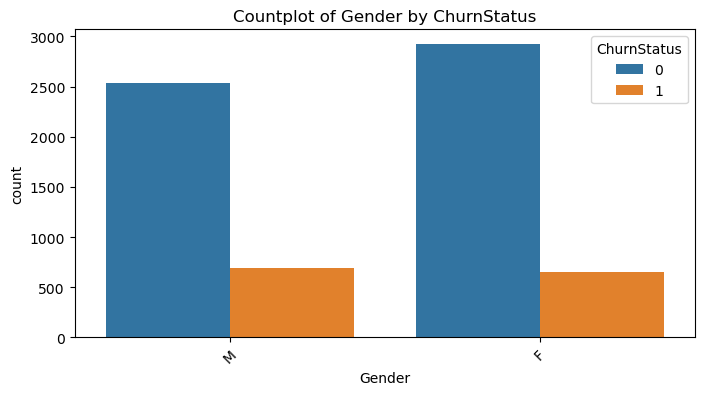

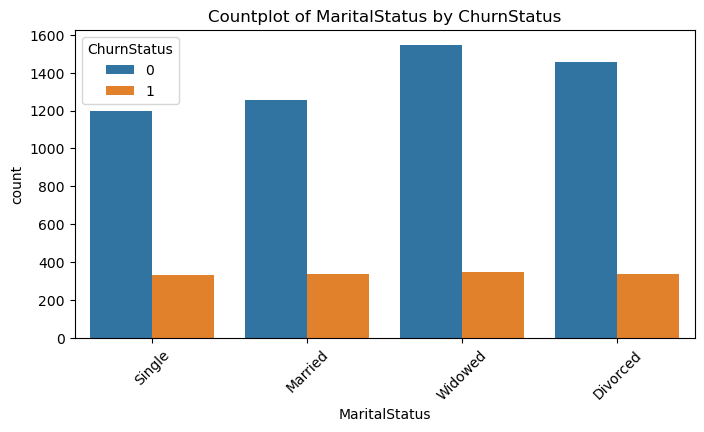

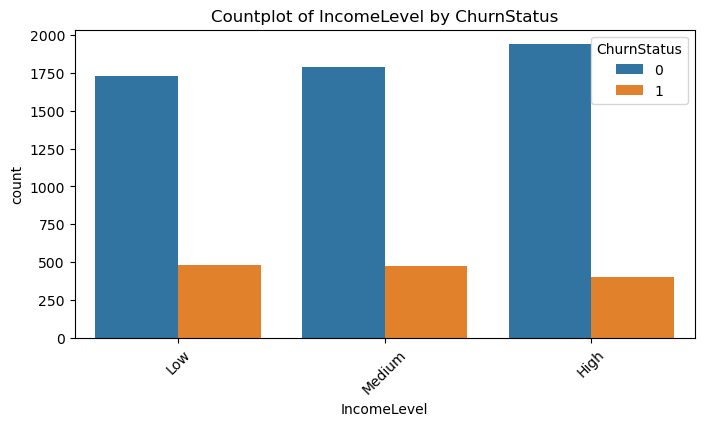

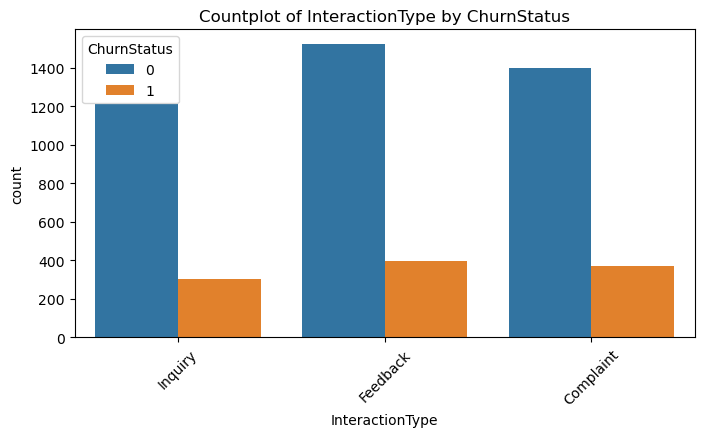

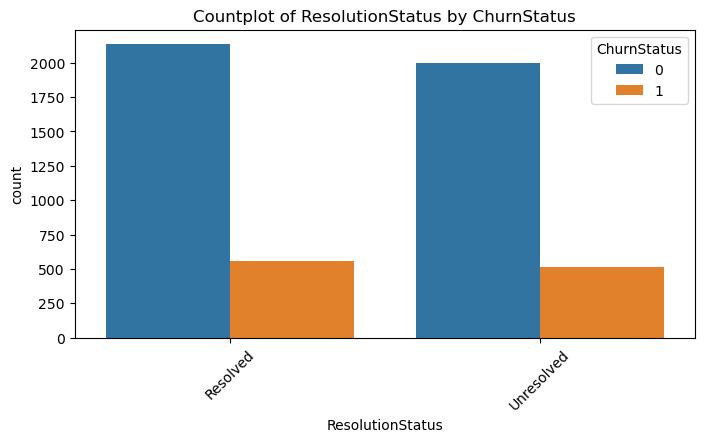

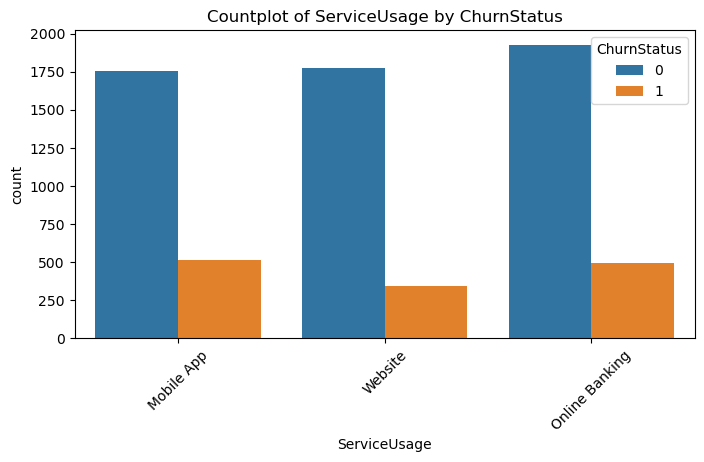

In [17]:
#tableau de distribution des variables catégorielles par rapport à la variable cible "ChurnStatus"
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], hue=df['ChurnStatus'])
    plt.title(f'Countplot of {col} by ChurnStatus')
    plt.xticks(rotation=45)
    plt.legend(title='ChurnStatus')
    plt.show()

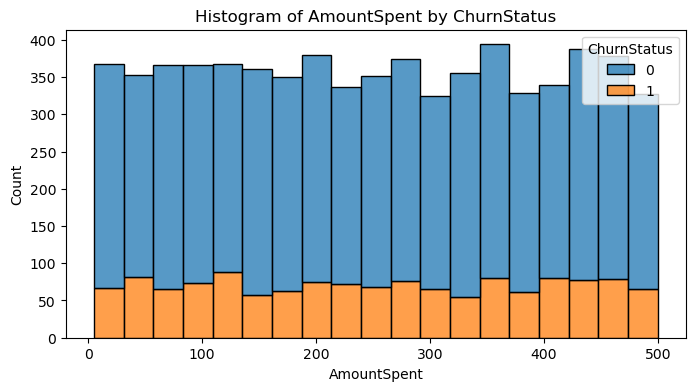

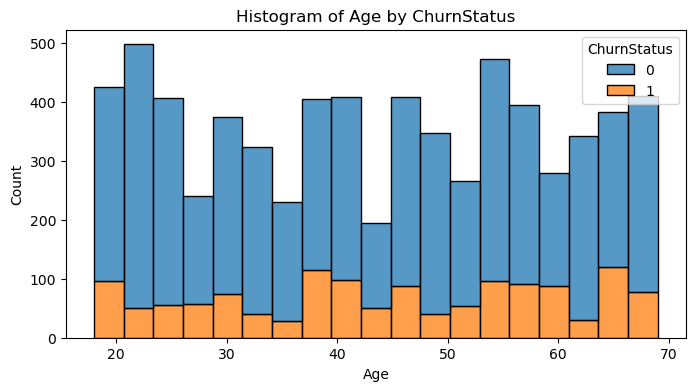

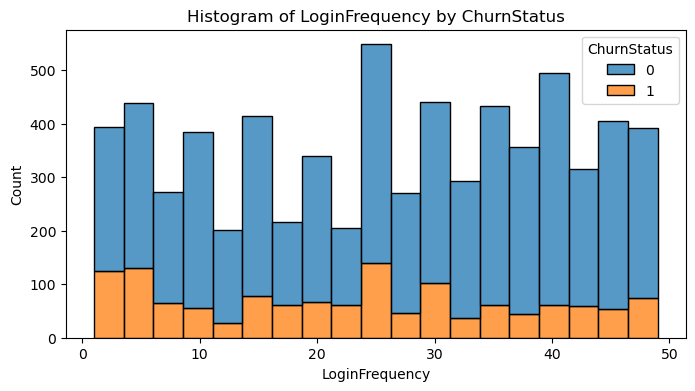

In [18]:
# relation entre les variables numeriques et la variable cible "ChurnStatus" avec des histogrammes
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=df[col], hue=df['ChurnStatus'], multiple='stack')
    plt.title(f'Histogram of {col} by ChurnStatus')
    plt.show()

<Axes: xlabel='Month', ylabel='count'>

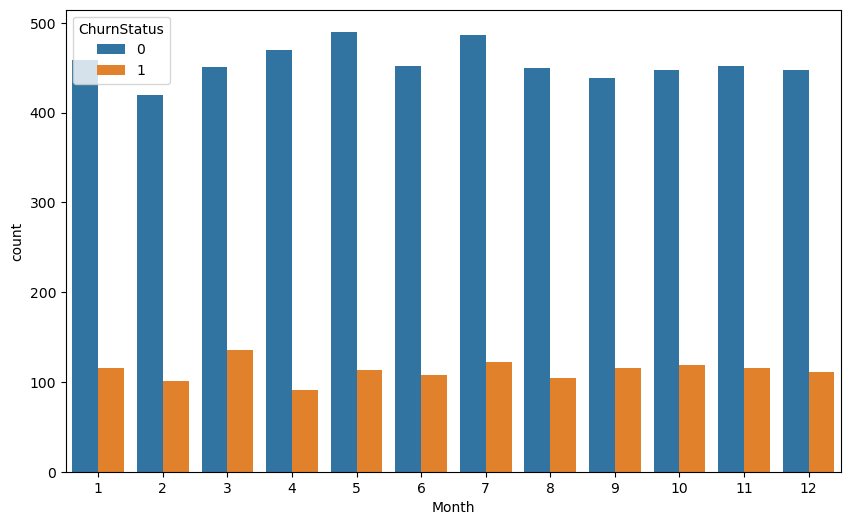

In [19]:
# graphique montrant les mois de l'année et le nombre de clients qui ont churné ou pas pour voir s'il y a une saisonnalité dans le churn
df['Month'] = df['TransactionDate'].dt.month
plt.figure(figsize=(10, 6))
sns.countplot(x=df['Month'], hue=df['ChurnStatus'])



In [20]:
# verification des lignes avec des valeurs manquantes
missing_rows = df[df.isnull().any(axis=1)]
missing_rows.head(20)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,Age,Gender,MaritalStatus,IncomeLevel,InteractionID,InteractionDate,InteractionType,ResolutionStatus,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,Month
24,5,1742,2022-02-21,475.69,Groceries,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,2
25,5,9349,2022-08-12,178.91,Furniture,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,8
26,5,7200,2022-12-02,373.51,Groceries,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,12
27,5,4938,2022-10-21,155.76,Electronics,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,10
28,5,5357,2022-07-04,308.80,Electronics,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,7
29,5,6791,2022-08-31,219.98,Furniture,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,8
30,5,7592,2022-12-21,218.98,Electronics,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,12
31,5,9249,2022-05-25,69.86,Groceries,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,5
37,7,8762,2022-10-24,86.73,Books,27,F,Married,High,NaN,NaT,NaN,NaN,0,2023-01-07,32,Mobile App,10
57,10,3487,2022-09-07,5.86,Furniture,68,M,Married,High,NaN,NaT,NaN,NaN,1,2023-01-13,29,Online Banking,9


# Nettoyage et pretraitement 

on observe dans l'ensemble des données des valeurs manquantes . Cependant le dataset est quasi propre c'est a dire zero valeur manquante , pas de doublons , pas d'outliers etc. 
On note aussi l'ensemble des données dans chaque variable une distribution uniforme a part que la variable cible est tres déséquilibrée. Dans les etapes qui vont suivre nous tenterons de normaliser cette deniere avant l'etape de la modelisation . 

In [21]:
# imputation des valeurs manquantes pour les variables catégorielles avec la valeur la plus fréquente 
from sklearn.impute import SimpleImputer
imputer_cat = SimpleImputer(strategy='most_frequent')
df_imputed_cat = pd.DataFrame(imputer_cat.fit_transform(df[categorical_cols]), columns=categorical_cols, index=df.index)

# verification des imputations
df_imputed_cat.isnull().sum()

ProductCategory     0
Gender              0
MaritalStatus       0
IncomeLevel         0
InteractionType     0
ResolutionStatus    0
ServiceUsage        0
dtype: int64

In [22]:
# encodage des variables nominales par la methode onehotencoder et des variables ordinales par la methode ordinalencoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# colonnes
nominal_cols = categorical_cols.drop('IncomeLevel')
ordinal_cols = ['IncomeLevel']

# compatibilité OneHotEncoder (sparse_output vs sparse)
try:
    ohe = OneHotEncoder(sparse_output=False, drop='first')
except TypeError:
    ohe = OneHotEncoder(sparse=False, drop='first')

# OrdinalEncoder — définir l'ordre réel si nécessaire
income_order = ['Low', 'Medium', 'High']  
oe = OrdinalEncoder(categories=[income_order])

# encoder nominales
ohe_arr = ohe.fit_transform(df[nominal_cols])
df_ohe = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(nominal_cols), index=df.index)

# encoder ordinale
ord_arr = oe.fit_transform(df[ordinal_cols])
df_ord = pd.DataFrame(ord_arr, columns=['IncomeLevel_ordinal'], index=df.index)

# concaténation finale (on retire les colonnes nominales + ordinales d'origine)
cols_to_drop = list(nominal_cols) + ordinal_cols
df_encoded = pd.concat([df.drop(columns=cols_to_drop), df_ohe, df_ord], axis=1)

# aperçu
print('Shape before:', df.shape)
print('Shape after :', df_encoded.shape)
df_encoded.head()


Shape before: (6812, 18)
Shape after : (6812, 27)


,CustomerID,TransactionID,TransactionDate,AmountSpent,Age,InteractionID,InteractionDate,ChurnStatus,LastLoginDate,LoginFrequency,...,MaritalStatus_Single,MaritalStatus_Widowed,InteractionType_Feedback,InteractionType_Inquiry,InteractionType_nan,ResolutionStatus_Unresolved,ResolutionStatus_nan,ServiceUsage_Online Banking,ServiceUsage_Website,IncomeLevel_ordinal
0,1,7194,2022-03-27,416.50,62,6363.0,2022-03-31,0,2023-10-21,34,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,7250,2022-08-08,54.96,65,3329.0,2022-03-17,1,2023-12-05,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,9660,2022-07-25,197.50,65,3329.0,2022-03-17,1,2023-12-05,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,2998,2022-01-25,101.31,65,3329.0,2022-03-17,1,2023-12-05,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,1228,2022-07-24,397.37,65,3329.0,2022-03-17,1,2023-12-05,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [23]:
# normalisation des variables numeriques avec la methode standardscaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols, index=df.index)
df_scaled.head()

,AmountSpent,Age,LoginFrequency
0,1.153881,1.225036,0.588556
1,-1.376296,1.421298,-1.473886
2,-0.378753,1.421298,-1.473886
3,-1.051923,1.421298,-1.473886
4,1.020003,1.421298,-1.473886


In [24]:
#  gerer les desequilibres de la variable cible "ChurnStatus" avec la methode SMOTE
# préparation pour SMOTE : n'utiliser que des colonnes numériques (pas de dates, ni d'IDs)
import numpy as np
from imblearn.over_sampling import SMOTE

# X → toutes les colonnes numériques sauf la cible
X = df_encoded.select_dtypes(include=[np.number]).drop(columns=['ChurnStatus'], errors='ignore')
# supprimer identifiants si présents
for idcol in ['CustomerID', 'TransactionID', 'InteractionID']:
    if idcol in X.columns:
        X = X.drop(columns=[idcol])

# y → variable cible
y = df_encoded['ChurnStatus']

print('Features used for resampling:', X.columns.tolist())
print('Dtypes:', X.dtypes.unique())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('Avant SMOTE :', y.value_counts().to_dict())
print('Après SMOTE  :', pd.Series(y_resampled).value_counts().to_dict())


Features used for resampling: ['AmountSpent', 'Age', 'LoginFrequency', 'Month', 'ProductCategory_Clothing', 'ProductCategory_Electronics', 'ProductCategory_Furniture', 'ProductCategory_Groceries', 'Gender_M', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'InteractionType_Feedback', 'InteractionType_Inquiry', 'InteractionType_nan', 'ResolutionStatus_Unresolved', 'ResolutionStatus_nan', 'ServiceUsage_Online Banking', 'ServiceUsage_Website', 'IncomeLevel_ordinal']
Dtypes: [dtype('float64') dtype('int64') dtype('int32')]
Avant SMOTE : {0: 5460, 1: 1352}
Après SMOTE  : {0: 5460, 1: 5460}
